In [56]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from pathlib import Path
import matplotlib.pyplot as plt

In [57]:
NOTEBOOK_DIR = Path(os.getcwd())           # server/notebook/
BASE_DIR     =  NOTEBOOK_DIR.parent     # server/app/ml/
DATASET_DIR = BASE_DIR / "dataset"   # server/app/ml/dataset/


# SPLITS_DIR should go through dataset/, not through BASE_DIR again
SPLITS_DIR = BASE_DIR / "dataset" / "splits"   # ← was duplicating app/ml
TRAIN_TXT  = SPLITS_DIR / "train_clean.txt"
VAL_TXT    = SPLITS_DIR / "val_clean.txt"
TEST_TXT   = SPLITS_DIR / "test.txt"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 40

print("BASE_DIR    :", BASE_DIR)
print("SPLITS_DIR  :", SPLITS_DIR)
print("TRAIN_TXT   :", TRAIN_TXT)

BASE_DIR    : c:\Users\siaot\OneDrive\Desktop\traffic-sign-ml\server\app\ml
SPLITS_DIR  : c:\Users\siaot\OneDrive\Desktop\traffic-sign-ml\server\app\ml\dataset\splits
TRAIN_TXT   : c:\Users\siaot\OneDrive\Desktop\traffic-sign-ml\server\app\ml\dataset\splits\train_clean.txt


In [58]:
def parse_txt(txt_path, base_dir, skip_unlabeled=True):
    paths, labels = [], []

    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            rel_path, raw_label = parts[0], parts[1]

            try:
                label = int(raw_label)
            except ValueError:
                continue

            if skip_unlabeled and label == -1:
                continue

            paths.append(os.path.join(base_dir, rel_path))
            labels.append(label - 1)

    return paths, labels


train_paths, train_labels = parse_txt(TRAIN_TXT, DATASET_DIR)
val_paths,   val_labels   = parse_txt(VAL_TXT,   DATASET_DIR)
test_paths,  _            = parse_txt(TEST_TXT,   DATASET_DIR, skip_unlabeled=True)

print(f"Train samples : {len(train_paths)}")
print(f"Val   samples : {len(val_paths)}")
print("Test  samples (unlabeled, skipped): 1141")

Train samples : 2368
Val   samples : 598
Test  samples (unlabeled, skipped): 1141


In [59]:
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

In [60]:
rotation_layer = tf.keras.layers.RandomRotation(0.08)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = rotation_layer(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

In [61]:
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=2000)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels)

print("Datasets ready.")

Datasets ready.


In [62]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [63]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, verbose=1
    )
]

In [64]:
print("=== Phase 1: Training head ===")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

=== Phase 1: Training head ===
Epoch 1/15


74/74 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.4945 - loss: 1.8255 - val_accuracy: 0.8328 - val_loss: 0.6360 - learning_rate: 0.0010
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7998 - loss: 0.6532 - val_accuracy: 0.8846 - val_loss: 0.3843 - learning_rate: 0.0010
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8598 - loss: 0.4529 - val_accuracy: 0.9231 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8927 - loss: 0.3430 - val_accuracy: 0.9214 - val_loss: 0.2396 - learning_rate: 0.0010
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9160 - loss: 0.2834 - val_accuracy: 0.9298 - val_loss: 0.2181 - learning_rate: 0.0010
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9286 - loss: 0.2382 - val_accuracy: 0.9415 - val_loss: 0.1757 - learning_rate: 0.0010
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9417 - loss: 0.1789 - val_accuracy: 0.95

In [65]:
print("=== Phase 2: Fine-tuning ===")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

=== Phase 2: Fine-tuning ===
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8965 - loss: 0.3318 - val_accuracy: 0.9130 - val_loss: 0.3005 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9529 - loss: 0.1519
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
74/74 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9510 - loss: 0.1503 - val_accuracy: 0.9314 - val_loss: 0.2670 - learning_rate: 1.0000e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9721 - loss: 0.0922 - val_accuracy: 0.9348 - val_loss: 0.2510 - learning_rate: 5.0000e-05
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9793 - loss: 0.0703
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
74/74 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9772 - loss: 0.0743 - val_accuracy: 0.9448 - val_loss: 0.1937 - learning_rate: 5.0000e-05


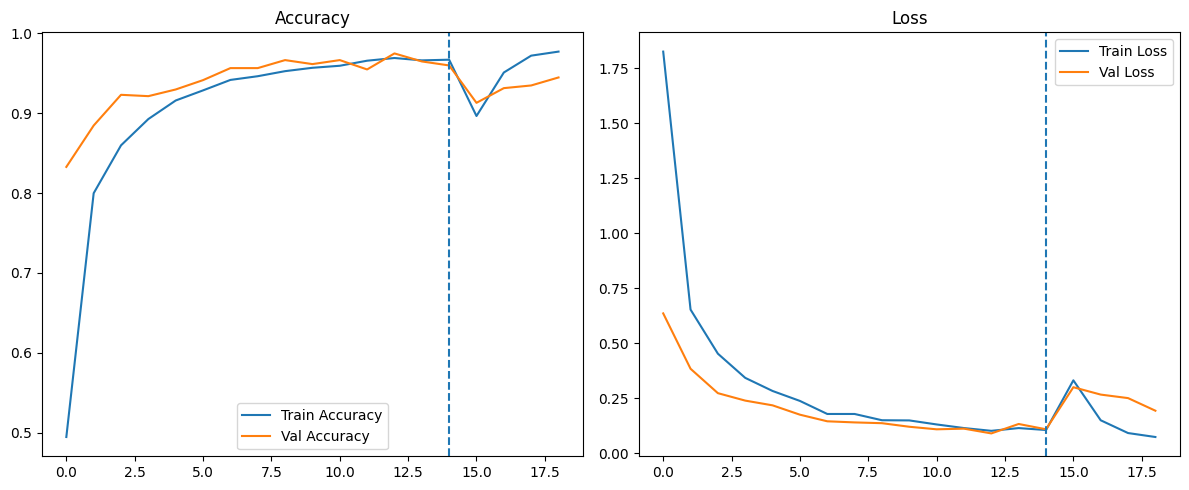

In [ ]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history1, history2, "accuracy")
val_acc = combine_history(history1, history2, "val_accuracy")
loss = combine_history(history1, history2, "loss")
val_loss = combine_history(history1, history2, "val_loss")

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.axvline(x=len(history1.history["accuracy"]) - 1, linestyle="--")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.axvline(x=len(history1.history["loss"]) - 1, linestyle="--")
plt.title("Loss")
plt.legend()

plt.tight_layout()
reports_dir = Path.cwd().parent / "dataset" / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(reports_dir / "training_curves.png", dpi=150)
plt.show()

In [71]:
model.save("traffic-sign/traffic_sign_model_v3.h5")
print("Model saved.")

Model saved.


In [72]:
CLASS_NAMES = [
    "Stop", "No Entry", "Left Curve Ahead", "Right Curve Ahead",
    "Reverse Turn Ahead", "Slippery Road", "Road Work",
    "Pedestrian Crossing", "Children Crossing", "Bike Lane",
    "Turn Right", "Turn Left", "Straight Ahead Only", "Pass on Right",
    "Pass on Left", "Roundabout", "U-Turn", "Speed Limit (60 km/h)",
    "Speed Limit (70 km/h)", "No Blowing of Horn", "No U-Turn",
    "Speed Limit (15 km/h)", "No Left Turn", "No Right Turn",
    "No Straight Proceeding", "No Parking", "Intersection Ahead",
    "Side Road Junction (Right)", "Speed Limit (20 km/h)",
    "Speed Limit (40 km/h)", "Pass on Either Side",
    "Side Road Junction (Diagonal)", "Speed Limit (30 km/h)",
    "No Entry for Four-Wheeled Vehicles", "Hospital",
    "Do Not Block Intersection", "Railroad Crossing",
    "Parking Area", "No Stopping / No Waiting", "T-Junction"
]

Predicting on 10 test images...


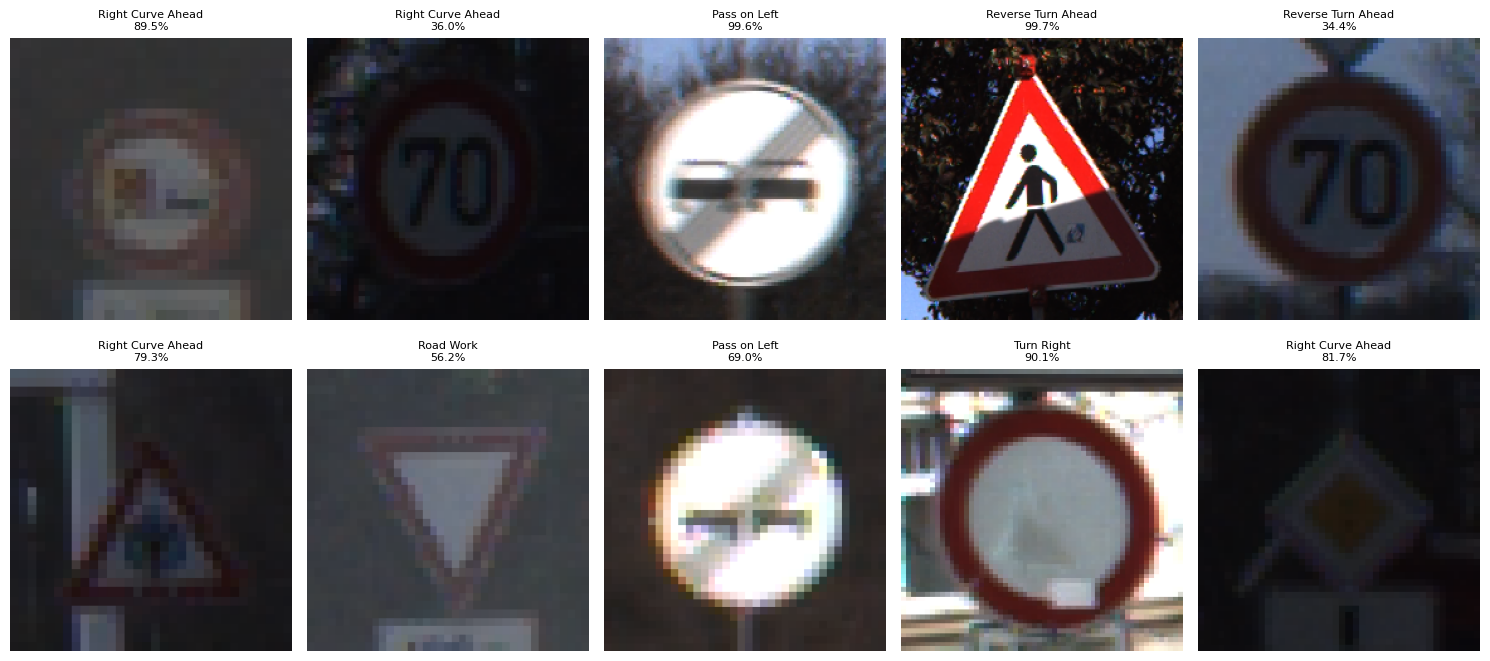

Saved → c:\Users\siaot\OneDrive\Desktop\traffic-sign-ml\server\app\ml\dataset\reports\test_predictions.png


In [78]:
def predict_test_images(model, test_txt_path, base_dir, num_samples=10):
    test_img_paths = []

    with open(test_txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            # test.txt has "Test/11412.png -1" — take only the path part
            rel_path  = parts[0]
            full_path = os.path.join(base_dir, rel_path)
            if os.path.exists(full_path):
                test_img_paths.append(full_path)

    if not test_img_paths:
        print("No test images found — check test.txt paths vs base_dir")
        print(f"  base_dir : {base_dir}")
        print(f"  sample   : {open(test_txt_path).readline().strip()}")
        return

    test_img_paths = test_img_paths[:num_samples]
    print(f"Predicting on {len(test_img_paths)} test images...")

    ncols = 5
    nrows = (len(test_img_paths) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
    axes = np.array(axes).flatten()

    for i, img_path in enumerate(test_img_paths):
        img = load_img(img_path, target_size=IMG_SIZE)
        arr = img_to_array(img) / 255.0

        pred       = model.predict(np.expand_dims(arr, 0), verbose=0)
        pred_class = np.argmax(pred)
        confidence = np.max(pred) * 100

        axes[i].imshow(img)
        axes[i].set_title(f"{CLASS_NAMES[pred_class]}\n{confidence:.1f}%", fontsize=8)
        axes[i].axis("off")

    # Hide unused subplot slots
    for j in range(len(test_img_paths), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    reports_dir = Path(os.getcwd()).parent / "dataset" / "reports"
    reports_dir.mkdir(parents=True, exist_ok=True)
    save_path = reports_dir / "test_predictions.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


# ── Call it here, OUTSIDE the function ───────────────────────────────────────
predict_test_images(model, TEST_TXT, DATASET_DIR, num_samples=10)